<a href="https://colab.research.google.com/github/mujtaba-farooq/Privacy-Preserving-Identity-Based-Data-Sharing-Scheme-Using-Proxy-Re-encryption-in-VANETs/blob/unitTesting/proposedSchemeCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CEll 1
!pip -q install py_ecc pandas matplotlib

In [ ]:
#CELL2
import time
import secrets
import hashlib
import statistics
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from py_ecc.optimized_bls12_381 import (
    G1, G2,
    add, multiply, neg,
    pairing,
    curve_order
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#CELL 3
def rand_scalar():
    return secrets.randbelow(curve_order - 1) + 1

s1 = rand_scalar()
s2 = rand_scalar()
s3 = rand_scalar()

g1_a = multiply(G1, s1)
g1_b = multiply(G1, s2)

g2_a = multiply(G2, s1)
g2_b = multiply(G2, s2)

gt_a = pairing(g2_a, g1_a, final_exponentiate=True)
gt_b = pairing(g2_b, g1_b, final_exponentiate=True)

def gt_div(a, b):
    try:
        return a / b
    except Exception:
        try:
            return a * b.inv()
        except Exception:
            return a * (b ** -1)

# E = exponentiation / scalar multiplication
def op_E_G1():
    return multiply(g1_a, s3)

def op_E_GT():
    return gt_a ** s3

# B = bilinear pairing
def op_B():
    return pairing(g2_a, g1_a, final_exponentiate=True)

# H = hash operation
def op_H():
    return hashlib.sha256(b"vehicle_identity_123").digest()

# M = multiplication
def op_M_G1():
    return add(g1_a, g1_b)

def op_M_GT():
    return gt_a * gt_b

# D = division / inversion
def op_D_G1():
    return add(g1_a, neg(g1_b))

def op_D_GT():
    return gt_div(gt_a, gt_b)

print("Benchmark operations defined.")

Benchmark operations defined.


In [ ]:
#CELL 4 RUN unit cost benchmarks
def benchmark_operation(name, operation_func, repeats=20, inner_loops=1, warmup=3):
    for _ in range(warmup):
        for _ in range(inner_loops):
            operation_func()

    timings = []

    for _ in range(repeats):
        start = time.perf_counter()

        for _ in range(inner_loops):
            operation_func()

        end = time.perf_counter()

        avg_ms = ((end - start) * 1000) / inner_loops
        timings.append(avg_ms)

    return {
        "Operation": name,
        "Mean_ms": statistics.mean(timings),
        "Median_ms": statistics.median(timings),
        "Std_ms": statistics.stdev(timings) if len(timings) > 1 else 0,
        "Min_ms": min(timings),
        "Max_ms": max(timings),
        "Repeats": repeats,
        "Inner_Loops": inner_loops
    }

benchmark_plan = [
    ("E_G1", op_E_G1, 30, 5),
    ("E_GT", op_E_GT, 20, 2),
    ("B", op_B, 10, 1),
    ("H", op_H, 50, 500),
    ("M_G1", op_M_G1, 50, 300),
    ("M_GT", op_M_GT, 50, 300),
    ("D_G1", op_D_G1, 50, 300),
    ("D_GT", op_D_GT, 50, 100),
]

results = []

for name, func, repeats, inner_loops in benchmark_plan:
    print(f"Benchmarking {name} ...")
    results.append(
        benchmark_operation(
            name=name,
            operation_func=func,
            repeats=repeats,
            inner_loops=inner_loops
        )
    )

raw_unit_df = pd.DataFrame(results)
display(raw_unit_df)

Benchmarking E_G1 ...
Benchmarking E_GT ...
Benchmarking B ...
Benchmarking H ...
Benchmarking M_G1 ...
Benchmarking M_GT ...
Benchmarking D_G1 ...
Benchmarking D_GT ...


,Operation,Mean_ms,Median_ms,Std_ms,Min_ms,Max_ms,Repeats,Inner_Loops
0,E_G1,14.013246,11.468002,3.938295,11.038462,21.784280,30,5
1,E_GT,58.981517,54.334366,28.684930,31.582331,118.637074,20,2
2,B,622.081894,585.439762,93.058518,572.163414,856.610532,10,1
3,H,0.000805,0.000789,0.000095,0.000778,0.001454,50,500
4,M_G1,0.026795,0.025582,0.004441,0.025284,0.049628,50,300
5,M_GT,0.084201,0.080690,0.010962,0.079977,0.146239,50,300
6,D_G1,0.026497,0.026258,0.000667,0.026031,0.029354,50,300
7,D_GT,6.335176,5.712470,1.558690,5.524533,10.814631,50,100


In [ ]:
#CELL 5 Convetr into E,B,M,D,H
COMBINE_MODE = "average"   # use "average" or "max"

def get_mean(op_name):
    return float(raw_unit_df.loc[raw_unit_df["Operation"] == op_name, "Mean_ms"].iloc[0])

E_G1 = get_mean("E_G1")
E_GT = get_mean("E_GT")
B_cost = get_mean("B")
H_cost = get_mean("H")
M_G1 = get_mean("M_G1")
M_GT = get_mean("M_GT")
D_G1 = get_mean("D_G1")
D_GT = get_mean("D_GT")

if COMBINE_MODE == "average":
    E_cost = (E_G1 + E_GT) / 2
    M_cost = (M_G1 + M_GT) / 2
    D_cost = (D_G1 + D_GT) / 2
elif COMBINE_MODE == "max":
    E_cost = max(E_G1, E_GT)
    M_cost = max(M_G1, M_GT)
    D_cost = max(D_G1, D_GT)
else:
    raise ValueError("COMBINE_MODE must be 'average' or 'max'.")

UNIT_COST = {
    "E": E_cost,
    "B": B_cost,
    "H": H_cost,
    "M": M_cost,
    "D": D_cost
}

unit_cost_df = pd.DataFrame([
    {"Symbol": "E", "Operation": "Exponentiation", "Measured_Unit_Cost_ms": UNIT_COST["E"]},
    {"Symbol": "B", "Operation": "Bilinear pairing", "Measured_Unit_Cost_ms": UNIT_COST["B"]},
    {"Symbol": "H", "Operation": "Hash operation", "Measured_Unit_Cost_ms": UNIT_COST["H"]},
    {"Symbol": "M", "Operation": "Multiplication", "Measured_Unit_Cost_ms": UNIT_COST["M"]},
    {"Symbol": "D", "Operation": "Division / inversion", "Measured_Unit_Cost_ms": UNIT_COST["D"]},
])

display(unit_cost_df)

print("Final measured unit costs:")
print(UNIT_COST)

,Symbol,Operation,Measured_Unit_Cost_ms
0,E,Exponentiation,36.497381
1,B,Bilinear pairing,622.081894
2,H,Hash operation,0.000805
3,M,Multiplication,0.055498
4,D,Division / inversion,3.180837


Final measured unit costs:
{'E': 36.4973812291646, 'B': 622.0818938000093, 'H': 0.0008053315600045608, 'M': 0.055497673333350886, 'D': 3.1808366705666837}


In [ ]:
#CELL 6, define uoverhead table
OPS = ["E", "B", "H", "M", "D"]

def counts(E=0, B=0, H=0, M=0, D=0):
    return {"E": E, "B": B, "H": H, "M": M, "D": D}

def add_counts(*items):
    total = {op: 0 for op in OPS}
    for item in items:
        for op in OPS:
            total[op] += item.get(op, 0)
    return total

def calculate_time(c):
    return sum(c[op] * UNIT_COST[op] for op in OPS)

def format_counts(c):
    parts = []
    for op in OPS:
        value = c[op]
        if value == 0:
            continue
        elif value == 1:
            parts.append(op)
        else:
            parts.append(f"{value}{op}")
    return " + ".join(parts) if parts else "0"


SCHEMES = {
    "AP-IBBPRE": {
        "Extract":  lambda k: counts(E=1, H=1),
        "Enc":      lambda k: counts(E=4, B=2, H=1, M=2),
        "RKeyGen":  lambda k: counts(E=k, B=1, H=k, M=k),
        "ReEnc":    lambda k: counts(M=2),
        "Dec(Or)":  lambda k: counts(B=1, D=2),
        "Dec(Re)":  lambda k: counts(B=k, H=1, M=k, D=3),
    },

    "VANETs IB-BPRE": {
        "Extract":  lambda k: counts(E=1, H=1, D=1),
        "Enc":      lambda k: counts(E=4, H=k, M=k, D=1),
        "RKeyGen":  lambda k: counts(E=4, B=1, H=k, M=k, D=k),
        "ReEnc":    lambda k: counts(E=3, B=3, H=2, M=2, D=2),
        "Dec(Or)":  lambda k: counts(E=4, B=2, H=1, M=8, D=3),
        "Dec(Re)":  lambda k: counts(E=6, B=3, H=2, M=8, D=2),
    },

    "PCL-BPRE": {
        "Extract":  lambda k: counts(E=2, H=1, D=1),
        "Enc":      lambda k: counts(E=8, B=4, H=4, M=4),
        "RKeyGen":  lambda k: counts(E=2*k+2, B=1, H=k+1, M=k, D=1),
        "ReEnc":    lambda k: counts(E=1, B=1, H=1),
        "Dec(Or)":  lambda k: counts(E=8, B=1, H=4, M=4, D=1),
        "Dec(Re)":  lambda k: counts(E=5, B=2, H=5, M=k+1, D=2),
    },

    "IBPRE-SHCD-MHCE": {
        "Extract":  lambda k: counts(E=5, M=2),
        "Enc":      lambda k: counts(E=8, B=1, H=1, M=5),
        "RKeyGen":  lambda k: counts(E=12, B=1, H=1, M=10),
        "ReEnc":    lambda k: counts(E=6, B=6, M=7, D=1),
        "Dec(Or)":  lambda k: counts(E=6, B=6, H=1, M=7, D=1),
        "Dec(Re)":  lambda k: counts(E=9, B=9, H=2, M=10, D=2),
    },

    "P2B": {
        "Extract":  lambda k: counts(E=1, H=1, D=1),
        "Enc":      lambda k: counts(E=5, B=1, H=1, M=1, D=1),
        "RKeyGen":  lambda k: counts(E=k+5, B=1, H=k+2, M=k+2, D=1),
        "ReEnc":    lambda k: counts(E=1, B=1, M=1, D=1),
        "Dec(Or)":  lambda k: counts(B=2, D=1),
        "Dec(Re)":  lambda k: counts(B=3, H=2, M=k+1, D=1),
    },

    "IB-BPRE-DF": {
        "Extract":  lambda k: counts(E=1, H=1, D=1),
        "Enc":      lambda k: counts(E=4, B=1, H=2, M=3),
        "RKeyGen":  lambda k: counts(),
        "ReEnc":    lambda k: counts(E=k+4, B=1, H=k, M=k+4),
        "Dec(Or)":  lambda k: counts(E=1, B=3, H=1, M=1, D=3),
        "Dec(Re)":  lambda k: counts(E=k, B=3, H=k, M=k, D=3),
    },

    "Proposed Scheme": {
        "Extract":  lambda k: counts(E=1, H=1),
        "Enc":      lambda k: counts(E=4, B=2, H=1, M=2),
        "RKeyGen":  lambda k: counts(E=k+3, B=1, H=k, M=2*k),
        "ReEnc":    lambda k: counts(B=k, H=k-1, M=2*k),
        "Dec(Or)":  lambda k: counts(B=1, D=2),
        "Dec(Re)":  lambda k: counts(B=2, D=3),
    },
}

print("Updated overhead formulas loaded.")

Updated overhead formulas loaded.


In [ ]:
#CELL 7 calculate execution time
k_values = [10, 20, 30, 40, 50]

rows = []

for k in k_values:
    for scheme, phases in SCHEMES.items():

        total_vehicle = counts()
        total_full = counts()

        for phase, formula in phases.items():
            c = formula(k)

            rows.append({
                "k": k,
                "Scheme": scheme,
                "Phase": phase,
                "Expression": format_counts(c),
                "E": c["E"],
                "B": c["B"],
                "H": c["H"],
                "M": c["M"],
                "D": c["D"],
                "Time_ms": calculate_time(c)
            })

            total_full = add_counts(total_full, c)

            # Vehicle-side total only includes:
            # Enc + RKeyGen + Dec(Or) + Dec(Re)
            if phase in ["Enc", "RKeyGen", "Dec(Or)", "Dec(Re)"]:
                total_vehicle = add_counts(total_vehicle, c)

        rows.append({
            "k": k,
            "Scheme": scheme,
            "Phase": "Total Vehicle",
            "Expression": format_counts(total_vehicle),
            "E": total_vehicle["E"],
            "B": total_vehicle["B"],
            "H": total_vehicle["H"],
            "M": total_vehicle["M"],
            "D": total_vehicle["D"],
            "Time_ms": calculate_time(total_vehicle)
        })

        rows.append({
            "k": k,
            "Scheme": scheme,
            "Phase": "Total Full",
            "Expression": format_counts(total_full),
            "E": total_full["E"],
            "B": total_full["B"],
            "H": total_full["H"],
            "M": total_full["M"],
            "D": total_full["D"],
            "Time_ms": calculate_time(total_full)
        })

df = pd.DataFrame(rows)

display(df.head(30))

,k,Scheme,Phase,Expression,E,B,H,M,D,Time_ms
0,10,AP-IBBPRE,Extract,E + H,1,0,1,0,0,36.498187
1,10,AP-IBBPRE,Enc,4E + 2B + H + 2M,4,2,1,2,0,1390.265113
2,10,AP-IBBPRE,RKeyGen,10E + B + 10H + 10M,10,1,10,10,0,987.618736
3,10,AP-IBBPRE,ReEnc,2M,0,0,0,2,0,0.110995
4,10,AP-IBBPRE,Dec(Or),B + 2D,0,1,0,0,2,628.443567
5,10,AP-IBBPRE,Dec(Re),10B + H + 10M + 3D,0,10,1,10,3,6230.917230
6,10,AP-IBBPRE,Total Vehicle,14E + 14B + 12H + 22M + 5D,14,14,12,22,5,9237.244647
7,10,AP-IBBPRE,Total Full,15E + 14B + 13H + 24M + 5D,15,14,13,24,5,9273.853828
8,10,VANETs IB-BPRE,Extract,E + H + D,1,0,1,0,1,39.679023
9,10,VANETs IB-BPRE,Enc,4E + 10H + 10M + D,4,0,10,10,1,149.733392


In [ ]:
#CELL 8 define graph settings
output_dir = Path("chapter5/images/unitTesting")
output_dir.mkdir(parents=True, exist_ok=True)

SELECTED_SCHEMES = list(SCHEMES.keys())

STYLE_MAP = {
    "AP-IBBPRE": {
        "color": "red", "marker": "*", "linestyle": "-",
        "linewidth": 1.8, "markersize": 9
    },
    "VANETs IB-BPRE": {
        "color": "blue", "marker": "o", "linestyle": "--",
        "linewidth": 1.8, "markersize": 6
    },
    "PCL-BPRE": {
        "color": "magenta", "marker": "s", "linestyle": "-.",
        "linewidth": 1.8, "markersize": 6
    },
    "IBPRE-SHCD-MHCE": {
        "color": "black", "marker": "x", "linestyle": ":",
        "linewidth": 1.8, "markersize": 7
    },
    "P2B": {
        "color": "orange", "marker": "^", "linestyle": "--",
        "linewidth": 1.8, "markersize": 7
    },
    "IB-BPRE-DF": {
        "color": "purple", "marker": "v", "linestyle": "-.",
        "linewidth": 1.8, "markersize": 7
    },
    "Proposed Scheme": {
        "color": "green", "marker": "D", "linestyle": "-",
        "linewidth": 2.3, "markersize": 7
    },
}

def plot_graph(phase, title, filename):
    plt.figure(figsize=(10, 6))

    for scheme in SELECTED_SCHEMES:
        temp = df[
            (df["Scheme"] == scheme) &
            (df["Phase"] == phase)
        ].sort_values("k")

        style = STYLE_MAP[scheme]

        plt.plot(
            temp["k"],
            temp["Time_ms"],
            label=scheme,
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=style["markersize"]
        )

    plt.xlabel("Number of receivers (k)")
    plt.ylabel("Time in millisecond")
    plt.title(title)
    plt.grid(True, linestyle=":", linewidth=0.7)
    plt.legend(fontsize=8)
    plt.tight_layout()

    png_path = output_dir / filename
    pdf_path = output_dir / filename.replace(".png", ".pdf")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)

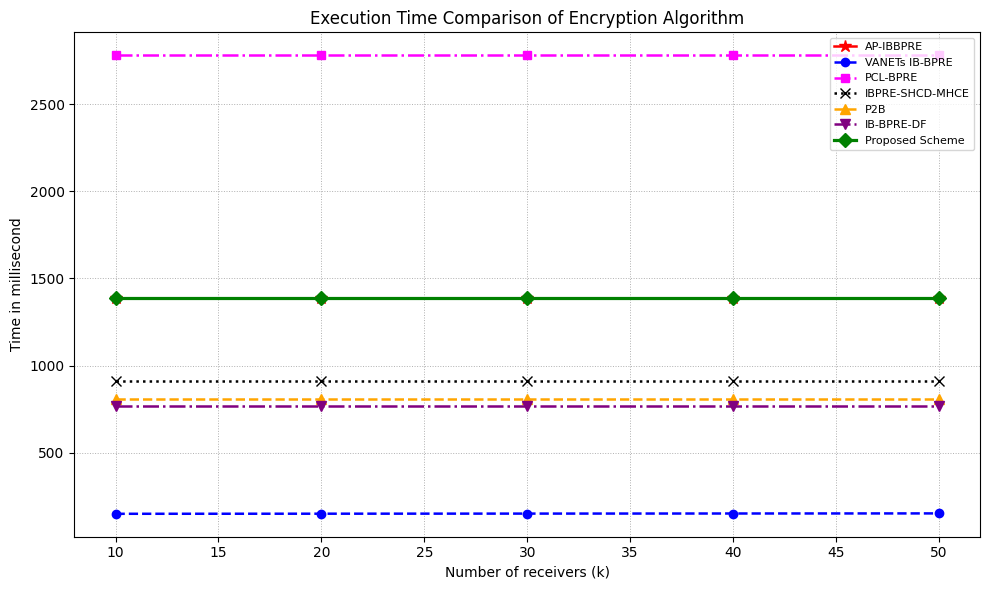

Saved: chapter5/images/unitTesting/encrypt_execution_time.png
Saved: chapter5/images/unitTesting/encrypt_execution_time.pdf


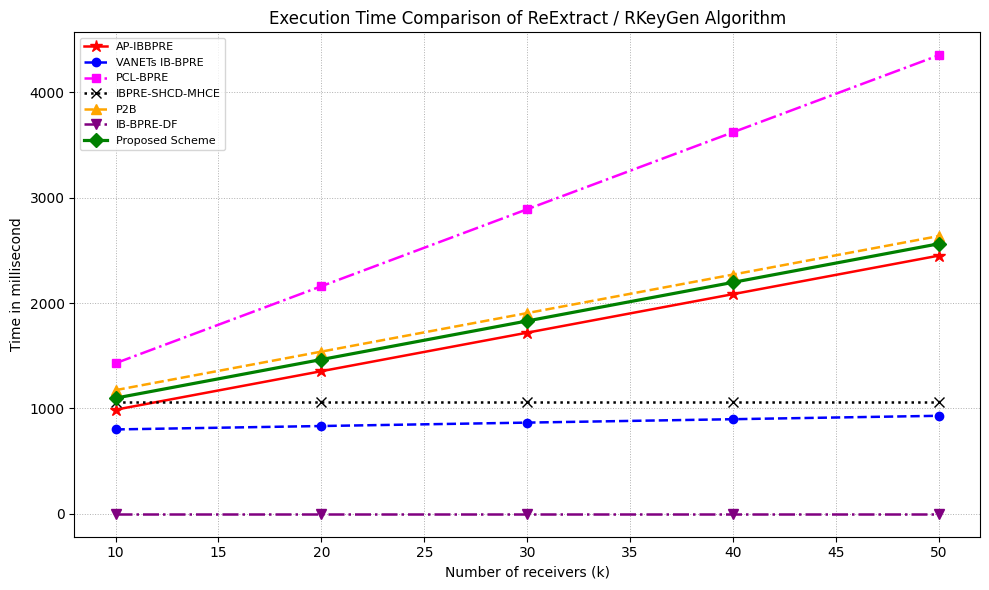

Saved: chapter5/images/unitTesting/reextract_rkeygen_execution_time.png
Saved: chapter5/images/unitTesting/reextract_rkeygen_execution_time.pdf


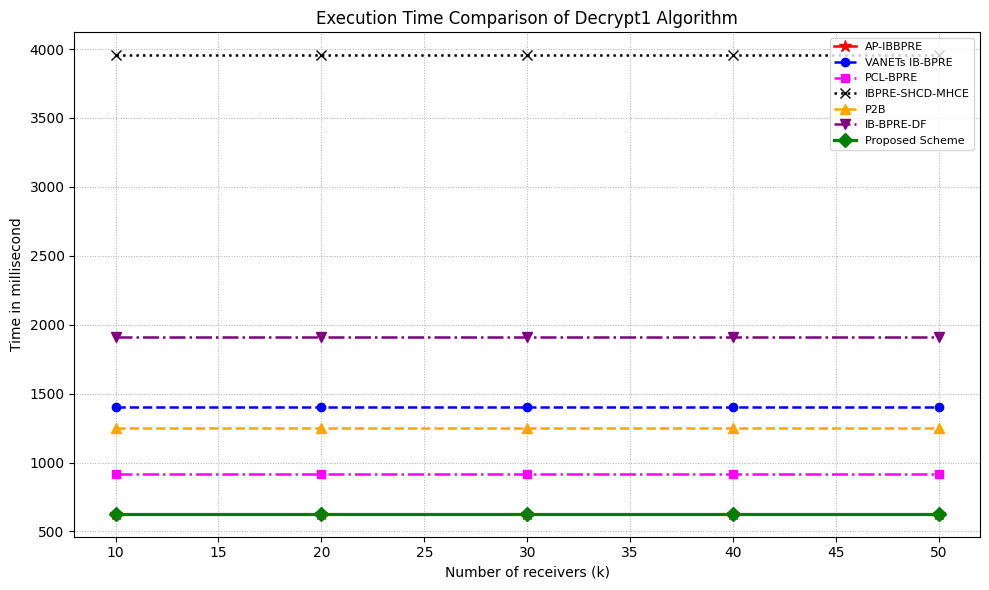

Saved: chapter5/images/unitTesting/decrypt1_execution_time.png
Saved: chapter5/images/unitTesting/decrypt1_execution_time.pdf


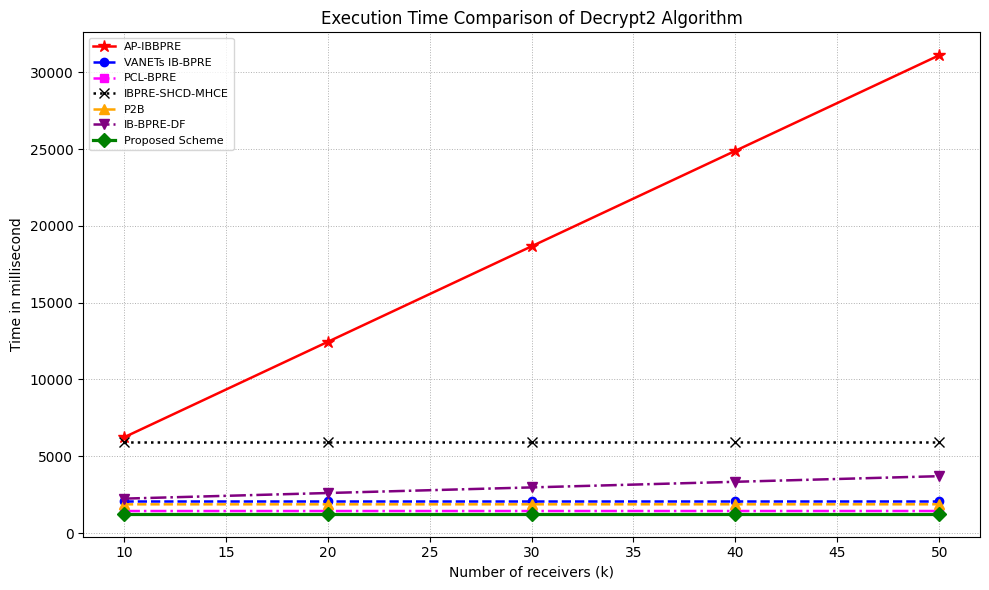

Saved: chapter5/images/unitTesting/decrypt2_execution_time.png
Saved: chapter5/images/unitTesting/decrypt2_execution_time.pdf


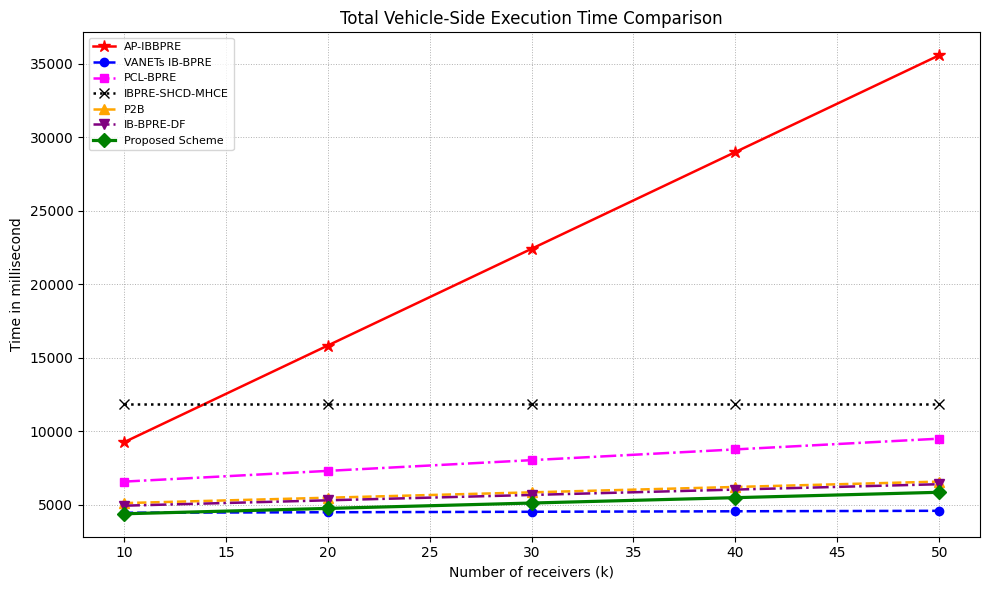

Saved: chapter5/images/unitTesting/total_vehicle_execution_time.png
Saved: chapter5/images/unitTesting/total_vehicle_execution_time.pdf


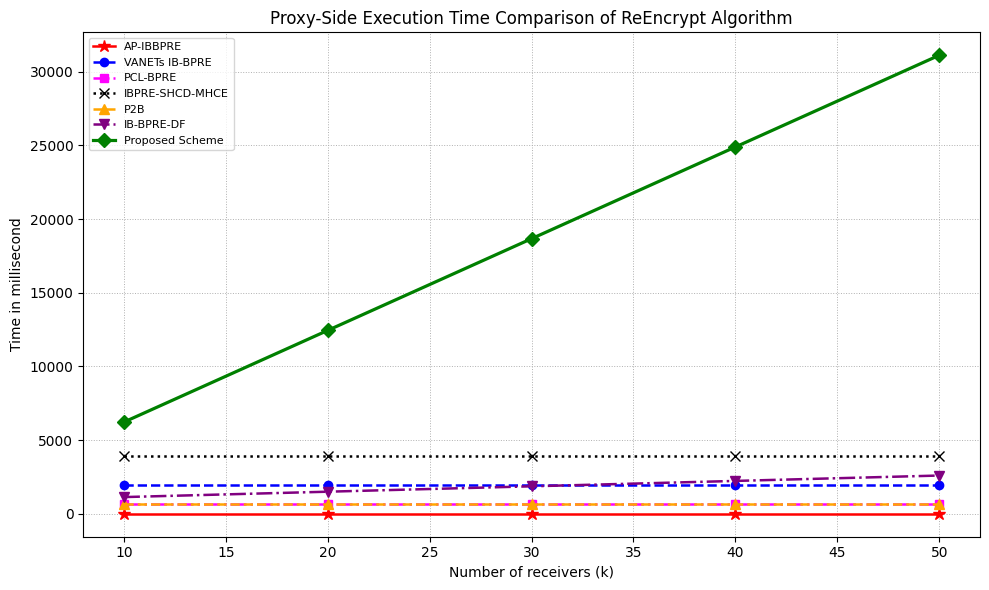

Saved: chapter5/images/unitTesting/proxy_reencrypt_execution_time.png
Saved: chapter5/images/unitTesting/proxy_reencrypt_execution_time.pdf


In [ ]:
#CELL 9 Generate Graphs
plot_graph(
    "Enc",
    "Execution Time Comparison of Encryption Algorithm",
    "encrypt_execution_time.png"
)

plot_graph(
    "RKeyGen",
    "Execution Time Comparison of ReExtract / RKeyGen Algorithm",
    "reextract_rkeygen_execution_time.png"
)

plot_graph(
    "Dec(Or)",
    "Execution Time Comparison of Decrypt1 Algorithm",
    "decrypt1_execution_time.png"
)

plot_graph(
    "Dec(Re)",
    "Execution Time Comparison of Decrypt2 Algorithm",
    "decrypt2_execution_time.png"
)

plot_graph(
    "Total Vehicle",
    "Total Vehicle-Side Execution Time Comparison",
    "total_vehicle_execution_time.png"
)

plot_graph(
    "ReEnc",
    "Proxy-Side Execution Time Comparison of ReEncrypt Algorithm",
    "proxy_reencrypt_execution_time.png"
)

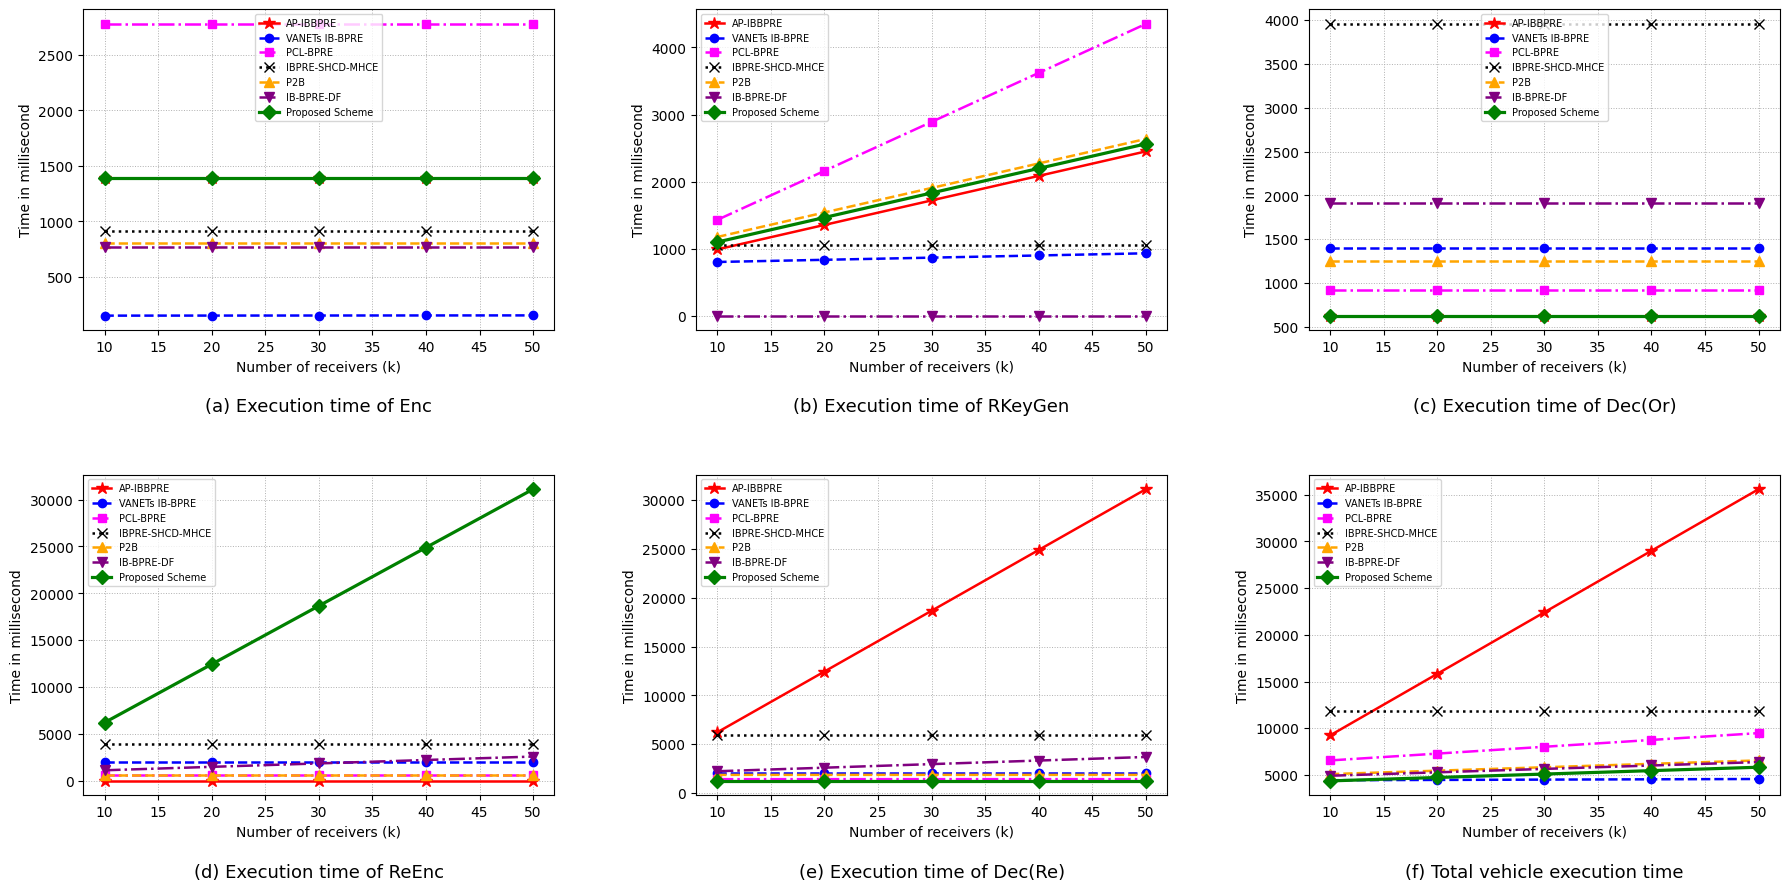

Saved combined_overhead_comparison.png and combined_overhead_comparison.pdf


In [ ]:
#CELL 10 generate 1 combined 2x3 graph
PHASES = [
    ("Enc", "(a) Execution time of Enc"),
    ("RKeyGen", "(b) Execution time of RKeyGen"),
    ("Dec(Or)", "(c) Execution time of Dec(Or)"),
    ("ReEnc", "(d) Execution time of ReEnc"),
    ("Dec(Re)", "(e) Execution time of Dec(Re)"),
    ("Total Vehicle", "(f) Total vehicle execution time")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, (phase, title) in zip(axes, PHASES):

    for scheme in SELECTED_SCHEMES:
        temp = df[
            (df["Scheme"] == scheme) &
            (df["Phase"] == phase)
        ].sort_values("k")

        style = STYLE_MAP[scheme]

        ax.plot(
            temp["k"],
            temp["Time_ms"],
            label=scheme,
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            markersize=style["markersize"]
        )

    ax.set_xlabel("Number of receivers (k)")
    ax.set_ylabel("Time in millisecond")
    ax.set_title(title, fontsize=13, y=-0.28)
    ax.grid(True, linestyle=":", linewidth=0.7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45, wspace=0.30)

plt.savefig(output_dir / "combined_overhead_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "combined_overhead_comparison.pdf", bbox_inches="tight")

plt.show()

print("Saved combined_overhead_comparison.png and combined_overhead_comparison.pdf")

In [ ]:
#Cell 11 Ranking Tables
selected_k = 50

print(f"Total vehicle-side ranking at k = {selected_k}")
vehicle_rank = df[
    (df["k"] == selected_k) &
    (df["Phase"] == "Total Vehicle")
].sort_values("Time_ms")

display(vehicle_rank[["Scheme", "Expression", "Time_ms"]])


print(f"Receiver-side Dec(Re) ranking at k = {selected_k}")
dec_re_rank = df[
    (df["k"] == selected_k) &
    (df["Phase"] == "Dec(Re)")
].sort_values("Time_ms")

display(dec_re_rank[["Scheme", "Expression", "Time_ms"]])


print(f"Proxy-side ReEnc ranking at k = {selected_k}")
reenc_rank = df[
    (df["k"] == selected_k) &
    (df["Phase"] == "ReEnc")
].sort_values("Time_ms")

display(reenc_rank[["Scheme", "Expression", "Time_ms"]])

Total vehicle-side ranking at k = 50


,Scheme,Expression,Time_ms
238,VANETs IB-BPRE,18E + 6B + 103H + 116M + 56D,4574.091758
278,Proposed Scheme,57E + 6B + 51H + 102M + 5D,5834.448111
270,IB-BPRE-DF,55E + 7B + 53H + 54M + 6D,6384.053801
262,P2B,60E + 7B + 55H + 104M + 4D,6562.955528
246,PCL-BPRE,123E + 8B + 64H + 109M + 4D,9484.657176
254,IBPRE-SHCD-MHCE,35E + 17B + 5H + 32M + 3D,11864.123000
230,AP-IBBPRE,54E + 54B + 52H + 102M + 5D,35584.887675


Receiver-side Dec(Re) ranking at k = 50


,Scheme,Expression,Time_ms
277,Proposed Scheme,2B + 3D,1253.706298
245,PCL-BPRE,5E + 2B + 5H + 51M + 2D,1435.846775
261,P2B,3B + 2H + 51M + D,1872.258510
237,VANETs IB-BPRE,6E + 3B + 2H + 8M + 2D,2092.037234
269,IB-BPRE-DF,50E + 3B + 50H + 50M + 3D,3703.472403
253,IBPRE-SHCD-MHCE,9E + 9B + 2H + 10M + 2D,5934.131736
229,AP-IBBPRE,50B + H + 50M + 3D,31116.412889


Proxy-side ReEnc ranking at k = 50


,Scheme,Expression,Time_ms
227,AP-IBBPRE,2M,0.110995
243,PCL-BPRE,E + B + H,658.580080
259,P2B,E + B + M + D,661.815609
235,VANETs IB-BPRE,3E + 3B + 2H + 2M + 2D,1982.212104
267,IB-BPRE-DF,54E + B + 50H + 54M,2595.977621
251,IBPRE-SHCD-MHCE,6E + 6B + 7M + D,3955.044971
275,Proposed Scheme,50B + 49H + 100M,31109.683919
